In [1]:
import sys
import numpy as np
sys.path.append('./src')

In [2]:
from GridWorld import GridWorld
from MonteCarlo import MonteCarlo

env = GridWorld(size=5, obstacles=[(1,1),(2,2)], icy_floors=[(1,2)])

# 3. Monte Carlo
## 3-1. MC Prediction

In [3]:
mc = MonteCarlo(env)

# uniform random policy
policy = np.full((len(env.states), len(env.actions)), 1/len(env.actions))

V_every, _ = mc.every_visit_pred(policy)
V_first, _ = mc.first_visit_pred(policy)

print("========= V - Every Visit =========")
print(V_every.reshape(5,5))
print("\n======== V - First Visit =========")
print(V_first.reshape(5,5))

========= V - Every Visit =========
[[-11.8304783  -10.42493934  -7.91172253  -6.52198812  -6.4049049 ]
 [-10.70812563   0.          -6.90717649  -5.76938373  -4.96543108]
 [ -9.2528878   -8.36101303   0.          -3.40628468  -3.55618814]
 [ -7.35169971  -5.59983367  -4.08727708  -1.77988634  -1.59110793]
 [ -6.50182761  -5.17092586  -3.74041014  -0.92410146   0.        ]]

======== V - First Visit =========
[[-15.44732886 -13.50103977 -10.48883778  -8.44643981  -7.40655591]
 [-13.27419406   0.          -9.01801357  -7.39212407  -7.39609886]
 [-10.47151499  -8.07509125   0.          -4.67246874  -4.49000198]
 [ -8.87094174  -5.77764485  -4.29445955  -3.13155402  -1.35014963]
 [ -8.1798561   -5.58416937  -3.60902478  -1.34895751   0.        ]]


## 3-2. Exploring Start

In [4]:
optimal_policy_f, optimal_Q_f = mc.ES_control(max_steps = 1000, gamma = 0.99, visit="first", max_iter = 10000)

print("========= Optimal Policy - ES, first visit =========")
print(optimal_policy_f)
print("\n========= Optimal Q - ES, first visit =========")
print(optimal_Q_f)

========= Optimal Policy - ES, first visit =========
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]

========= Optimal Q - ES, first visit =========
[[-2.51575076 -0.41411438 -1.51184546 -3.46819991]
 [-3.32367296 -2.93481826 -1.48220713 -2.61351809]
 [-2.92805482 -4.4153603  -1.67003058 -5.24082466]
 [-2.24057706 -0.11956166 -4.80113768 -0.53292806]
 [-1.4049236   0.44425652 -0.98280042 -1.77637607]
 [-0.85153194 -0.31936528 -1.64637258 -1.76439364]
 [ 0.          0.          0.          0.        ]
 [-2.52322295 -4.02863371 -4.28224721 -2.79408515]
 [-0.62553756  0.01594474 -4.57429832 -0.00681747]
 [ 0.33093879  0.65671983 -0.13840562 -1.16792518]
 [-1.0981756

In [5]:
optimal_policy_e, optimal_Q_e = mc.ES_control(max_steps = 1000, gamma = 0.99, visit="every", max_iter = 10000)

print("========= Optimal Policy - ES, every visit =========")
print(optimal_policy_e)
print("\n========= Optimal Q - ES, every visit =========")
print(optimal_Q_e)

========= Optimal Policy - ES, every visit =========
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]

========= Optimal Q - ES, every visit =========
[[-4.87040754e+01 -2.14167116e+01 -2.14665685e+01 -4.62709156e+00]
 [-8.14100380e+01 -2.10911231e+01 -2.10284193e+01 -4.18121362e+00]
 [-6.58404492e+01 -5.15777693e+00 -2.20957304e+01 -2.85563645e+00]
 [-8.16571041e+01 -3.25233033e+00 -1.49023288e+01 -2.18983709e+00]
 [-8.07323046e+01 -8.59894942e-01 -1.39857668e+01 -4.21455924e+01]
 [-8.04062017e+00 -1.38628915e+01 -8.13654326e+01 -1.25065591e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.10013556e+00 -7.86694973e+00 -1.38775021e+01 -4.

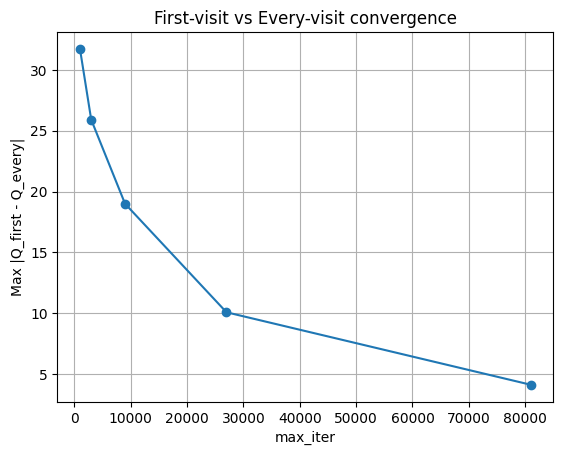

In [11]:
import matplotlib.pyplot as plt

max_iters = [1000, 3000, 9000, 27000, 81000]
diffs = []

for max_iter in max_iters:
    _, Q_f = mc.ES_control(visit="first", max_iter=max_iter)
    _, Q_e = mc.ES_control(visit="every", max_iter=max_iter)
    diffs.append(np.max(np.abs(Q_f - Q_e)))

plt.plot(max_iters, diffs, marker='o')
plt.xlabel("max_iter")
plt.ylabel("Max |Q_first - Q_every|")
plt.title("First-visit vs Every-visit convergence")
plt.grid()
plt.show()